### In this notebook we first generate the GMM training data and then used the trained models to compute the maximum mean discrepancy (MMD) followed by comparing to training data (treated as the "ground truth")

In [ ]:
#Generate data for training 

import numpy as np
import pandas as pd

def sample_from_target_df(a=2.0, b=0.5, c=0.0, n_samples=10000, seed=0):
    np.random.seed(seed)
    cov = np.array([[b**2, c], [c, b**2]])
    mean1 = np.array([-a, 0])
    mean2 = np.array([a, 0])

    z = np.random.binomial(1, 0.5, size=n_samples)
    samples = np.array([
        np.random.multivariate_normal(mean1, cov) if zi == 0
        else np.random.multivariate_normal(mean2, cov)
        for zi in z
    ])
    
    df = pd.DataFrame(samples, columns=["x", "y"])
    df["a"] = a
    df["b"] = b
    df["c"] = c
    return df[["a", "b", "c", "x", "y"]]

In [ ]:
# Define a list of parameter sets
param_list = [
    (0.2, 0.5, 0.0),
    (0.2, 0.5, 0.2),
    (0.6, 0.8, 0.4),
    (1., 0.8, 0.2),
    (1.5, 0.6, -0.3),
]

# Sample from all of them and concatenate
all_dfs = [
    sample_from_target_df(a, b, c, n_samples=40000, seed=10**i)
    for i, (a, b, c) in enumerate(param_list)
]

# Combine into a single DataFrame
combined_df = pd.concat(all_dfs, ignore_index=True)

#Name of the output file can be changed as needed
#combined_df.to_csv("gaussian_mixture_samples40k.csv", index=False, header=False, sep=" ")

In [ ]:
#This cell contains the MMD functions used in the paper - adapted from https://www.onurtunali.com/ml/2019/03/08/maximum-mean-discrepancy-in-machine-learning.html
from scipy.stats import entropy
import numpy as np

def MMD(x, y, kernel):
    """Emprical maximum mean discrepancy. The lower the result
       the more evidence that distributions are the same.

    Args:
        x: first sample, distribution P
        y: second sample, distribution Q
        kernel: kernel type such as "multiscale" or "rbf"
    """
    xx, yy, zz = torch.mm(x, x.t()), torch.mm(y, y.t()), torch.mm(x, y.t())
    rx = (xx.diag().unsqueeze(0).expand_as(xx))
    ry = (yy.diag().unsqueeze(0).expand_as(yy))

    dxx = rx.t() + rx - 2. * xx # Used for A in (1)
    dyy = ry.t() + ry - 2. * yy # Used for B in (1)
    dxy = rx.t() + ry - 2. * zz # Used for C in (1)

    XX, YY, XY = (torch.zeros(xx.shape).to(device),
                  torch.zeros(xx.shape).to(device),
                  torch.zeros(xx.shape).to(device))

    if kernel == "multiscale":

        bandwidth_range = [0.2, 0.5, 0.9, 1.3]
        for a in bandwidth_range:
            XX += a**2 * (a**2 + dxx)**-1
            YY += a**2 * (a**2 + dyy)**-1
            XY += a**2 * (a**2 + dxy)**-1

    if kernel == "rbf":

        bandwidth_range = [10, 15, 20, 50]
        for a in bandwidth_range:
            XX += torch.exp(-0.5*dxx/a)
            YY += torch.exp(-0.5*dyy/a)
            XY += torch.exp(-0.5*dxy/a)

    return torch.mean(XX + YY - 2. * XY)


def mmd_batched_no_replacement(x, y, kernel_fn, batch_size=5000):
    n_samples = min(x.size(0), y.size(0))
    n_batches = n_samples // batch_size

    # If the data are smaller than one batch, just compute directly
    if n_batches == 0:
        return MMD(x, y, kernel_fn).item(), 0.0

    # Randomly shuffle indices
    perm_x = torch.randperm(x.size(0))
    perm_y = torch.randperm(y.size(0))

    vals = []
    for i in range(n_batches):
        bx = x[perm_x[i*batch_size : (i+1)*batch_size]]
        by = y[perm_y[i*batch_size : (i+1)*batch_size]]
        vals.append(MMD(bx, by, kernel_fn).item())

    vals = torch.tensor(vals)
    return vals.mean().item(), vals.std().item()

### Here the files containing MMD for different trained models is computed and stored in a csv file

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch


# Change file path as needed
true_data = pd.read_csv(
    '/home/ssingh_hpc/BiFra01proj/GMM/gaussian_mixture_samples40k.csv',
    sep='\s+',
    header=None,
    names=['a', 'b', 'c', 'GMMx', 'GMMy']
)

# Convert all columns to numeric (in case they are strings)
true_data = true_data.apply(pd.to_numeric, errors='coerce')

# Define parameter list
params = [
    (0.2, 0.5, 0.0),
    (0.2, 0.5, 0.2),
    (0.6, 0.8, 0.4),
    (1.0, 0.8, 0.2),
    (1.5, 0.6, -0.3)
]
a, b, c = 0.2, 0.5, 0.2
base_path = "/home/ssingh_hpc/BiFra01proj/GMM/eval_results40k_w128"

made_dirs = [f"made{i}" for i in [8, 9, 10, 11, 12]]
samples_true = sample_from_target(a, b, c, n_samples=40000, seed=10)
samples_true = torch.tensor(samples_true, dtype=torch.float32).to(device)

# storage
mmd_means = []
mmd_stds = []
made_numbers = []

all_mmd_vals = []   # store tuples (made, run_val)

for made_dir in made_dirs:
    made = int(made_dir.replace("made", ""))
    run_vals = []

    for run_idx in range(1, 6):  # run1 ... run5
        file_path = os.path.join(
            base_path,
            f"{made_dir}/run{run_idx}",
            f"GMM_vol{a}_mass{b}_beta{c}.npz",
        )

        if not os.path.exists(file_path):
            print(f"File not found: {file_path}")
            continue

        data = np.load(file_path, allow_pickle=True)["result"]
        samples_sim = np.stack([data[3], data[4]], axis=1)
        samples_sim = torch.tensor(samples_sim, dtype=torch.float32).to(device)

        mean_val, std_val = mmd_batched_no_replacement(
            samples_true, samples_sim, "multiscale", batch_size=10000
        )
        run_vals.append(mean_val)
        all_mmd_vals.append((made, mean_val))  # store made–run pair

        print(f"{made_dir}/run{run_idx}: MMD mean={mean_val:.6f}, std={std_val:.6f}")

# convert to array for plotting
all_mmd_vals = np.array(all_mmd_vals)
#np.savetxt('mmd_vals_10k.txt', all_mmd_vals, fmt='%.12f')


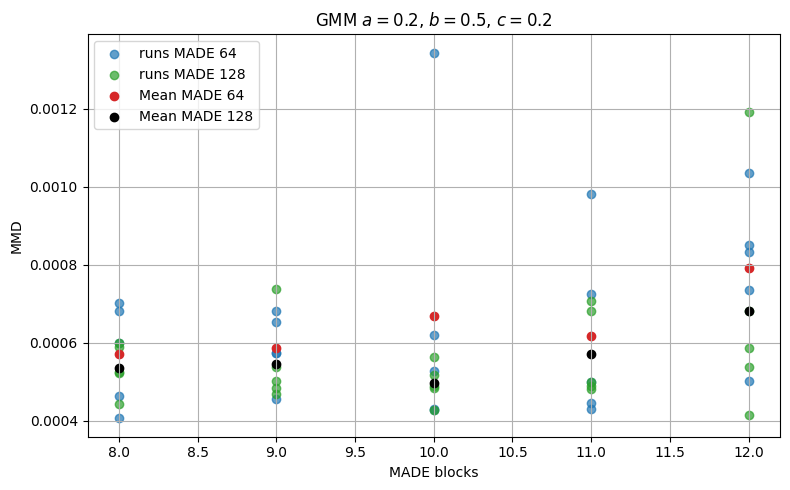

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(all_mmd_vals[:, 0], all_mmd_vals[:, 1],
            color="tab:blue", alpha=0.7, label=f"runs MADE 64")
plt.scatter(all_mmd_vals[:, 0], all_mmd_vals[:, 1],
            color="tab:green", alpha=0.7, label=f"runs MADE 128")

unique_mades = np.unique(all_mmd_vals[:, 0])
mean_mmds64 = [np.mean(all_mmd_vals[all_mmd_vals[:, 0] == m, 1]) for m in unique_mades]
mean_mmds128 = [np.mean(all_mmd_vals[all_mmd_vals[:, 0] == m, 1]) for m in unique_mades]

plt.scatter(unique_mades, mean_mmds64,color="tab:red", label="Mean MADE 64")
plt.scatter(unique_mades, mean_mmds128,color="black", label="Mean MADE 128")

plt.xlabel("MADE blocks")
plt.ylabel("MMD")
plt.title(r"GMM $a=0.2$, $b=0.5$, $c=0.2$")
plt.grid(True)
plt.legend()
plt.tight_layout()
#plt.savefig("GMM020502_MMD_40k.pdf")
plt.show()

### Main MMD storage in a proper way

In [ ]:
import numpy as np
import pandas as pd
import os
import torch

# Change file path as needed
true_data = pd.read_csv(
    '/home/ssingh_hpc/BiFra01proj/GMM/gaussian_mixture_samples.csv',
    sep='\s+',
    header=None,
    names=['a', 'b', 'c', 'GMMx', 'GMMy']
)
true_data = true_data.apply(pd.to_numeric, errors='coerce')

# Define parameter list
params = [
    (0.2, 0.5, 0.0),
    (0.2, 0.5, 0.2),
    (0.6, 0.8, 0.4),
    (1.0, 0.8, 0.2),
    (1.5, 0.6, -0.3)
]

base_path = "/home/ssingh_hpc/BiFra01proj/GMM/eval_results10k_w128"
made_list = [8, 9, 10, 11, 12]
run_indices = range(1, 6)  # run1 ... run5

# container for all results
records = []

# --- Loop over parameter sets ---
for (a, b, c) in params:
    # get true samples
    tol = 1e-6

    subset = true_data[
        np.isclose(true_data['a'], a, atol=tol) &
        np.isclose(true_data['b'], b, atol=tol) &
        np.isclose(true_data['c'], c, atol=tol)
    ]

    if subset.empty:
        print(f"No true samples found for a={a}, b={b}, c={c}")
        continue

    samples_true = subset[['GMMx', 'GMMy']].to_numpy()
    samples_true = torch.tensor(samples_true, dtype=torch.float32).to(device)

    for made in made_list:
        for run in run_indices:
            file_path = os.path.join(
                base_path,
                f"made{made}",
                f"run{run}",
                f"GMM_vol{a}_mass{b}_beta{c}.npz"
            )

            if not os.path.exists(file_path):
                print(f"File not found: {file_path}")
                continue

            data = np.load(file_path, allow_pickle=True)["result"]
            samples_sim = np.stack([data[3], data[4]], axis=1)
            samples_sim = torch.tensor(samples_sim, dtype=torch.float32).to(device)

            mean_val, std_val = mmd_batched_no_replacement(
                samples_true, samples_sim, "multiscale", batch_size=10000
            )

            records.append({
                "a": a,
                "b": b,
                "c": c,
                "made": made,
                "run": run,
                "mmd_mean": float(mean_val),
                "mmd_std": float(std_val)
            })

            print(f"a={a}, b={b}, c={c}, MADE={made}, run={run}: "
                  f"MMD mean={mean_val:.6f}, std={std_val:.6f}")

# convert to DataFrame
results_df = pd.DataFrame(records)

# compute summary statistics (optional)
summary_df = (
    results_df.groupby(["a", "b", "c", "made"])
    .agg(mmd_mean_avg=("mmd_mean", "mean"),
         mmd_std_avg=("mmd_std", "mean"),
         mmd_mean_std=("mmd_mean", "std"))
    .reset_index()
)

# save results if needed
#results_df.to_csv("all_mmd_results_10k_128.csv", index=False)
#summary_df.to_csv("summary_mmd_results_10k_128.csv", index=False)

print("\nAll runs stored")


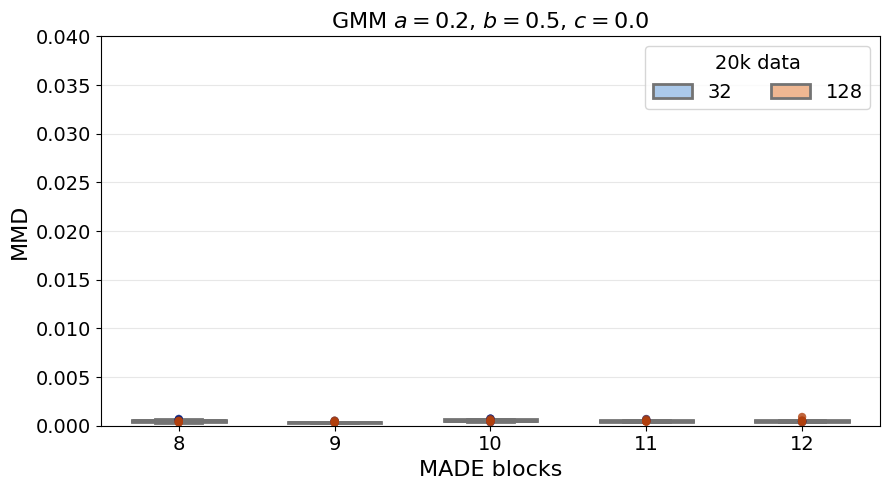

In [3]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

#Loading the results:
'''params = [
    (0.2, 0.5, 0.0),
    (0.2, 0.5, 0.2),
    (0.6, 0.8, 0.4),
    (1.0, 0.8, 0.2),
    (1.5, 0.6, -0.3)
]'''
a,b,c = 0.2,0.5,0.0
#a,b,c = 1.5,0.6,-0.3
N1=32
N2=128
tol=1e-6
data1 = pd.read_csv('/home/ssingh_hpc/BiFra01proj/GMM/all_mmd_results_20k_32.csv')
data1 = data1[np.isclose(data1['a'],a,atol=tol) & np.isclose(data1['b'],b,atol=tol) & np.isclose(data1['c'],c,atol=tol)]

data2 = pd.read_csv('/home/ssingh_hpc/BiFra01proj/GMM/all_mmd_results_20k_128.csv')
data2 = data2[np.isclose(data2['a'],a,atol=tol) & np.isclose(data2['b'],b,atol=tol) & np.isclose(data2['c'],c,atol=tol)]

# --- prepare long-form dataframe ---
df1 = data1[['made', 'mmd_mean']].copy()
df1['width'] = f'{N1}'

df2 = data2[['made', 'mmd_mean']].copy()
df2['width'] = f'{N2}'

df = pd.concat([df1, df2], ignore_index=True)

# make categorical x so spacing is uniform
df['made'] = df['made'].astype(str)

# --- plot ---
plt.figure(figsize=(9, 5))

# boxplot (summary)
sns.boxplot(
    data=df,
    x='made',
    y='mmd_mean',
    hue='width',
    width=0.6,
    dodge=False,
    fliersize=0,
    linewidth=2,
    palette='pastel'
)

# strip plot (runs)
sns.stripplot(
    data=df,
    x='made',
    y='mmd_mean',
    hue='width',
    dodge=False,
    jitter=0.0,
    alpha=0.8,
    size=6,
    palette='dark'
)

# clean up duplicated legends
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title='20k data',fontsize=14,title_fontsize=14,ncol=2)

plt.xlabel("MADE blocks",fontsize=16)
plt.ylabel("MMD",fontsize=16)
plt.title(rf"GMM $a={a}$, $b={b}$, $c={c}$",fontsize=16)
plt.grid(True, axis='y', alpha=0.3)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=14)
plt.ylim(0,0.04)

plt.tight_layout()
#plt.savefig(f"GMM_a{a}_b{b}_c{c}_made_width_comparison20k_v1.pdf")
plt.show()


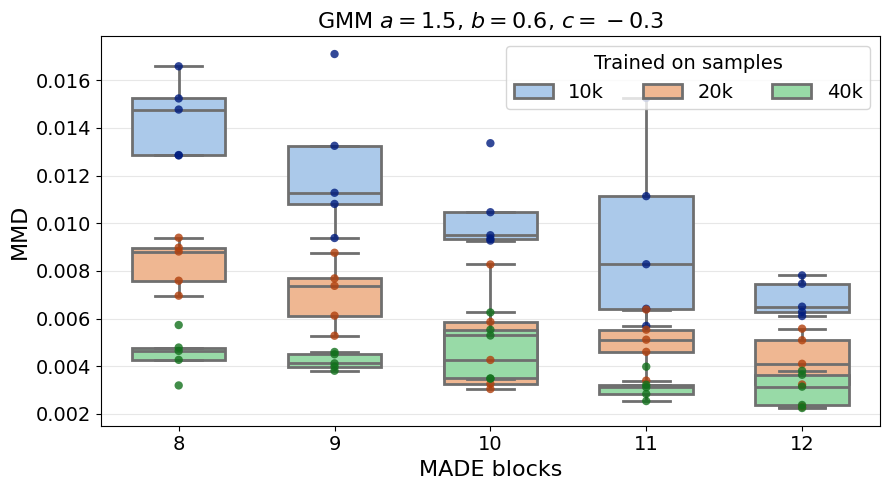

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

#Loading the results:
'''params = [
    (0.2, 0.5, 0.0),
    (0.2, 0.5, 0.2),
    (0.6, 0.8, 0.4),
    (1.0, 0.8, 0.2),
    (1.5, 0.6, -0.3)
]'''
#a,b,c = 0.2,0.5,0.0
a,b,c = 1.5,0.6,-0.3
N1=10
N2=20
N3=40
tol=1e-6
data1 = pd.read_csv('/home/ssingh_hpc/BiFra01proj/GMM/all_mmd_results_10k_128.csv')
data1 = data1[np.isclose(data1['a'],a,atol=tol) & np.isclose(data1['b'],b,atol=tol) & np.isclose(data1['c'],c,atol=tol)]

data2 = pd.read_csv('/home/ssingh_hpc/BiFra01proj/GMM/all_mmd_results_20k_128.csv')
data2 = data2[np.isclose(data2['a'],a,atol=tol) & np.isclose(data2['b'],b,atol=tol) & np.isclose(data2['c'],c,atol=tol)]

data3 = pd.read_csv('/home/ssingh_hpc/BiFra01proj/GMM/all_mmd_results_40k_128.csv')
data3 = data3[np.isclose(data3['a'],a,atol=tol) & np.isclose(data3['b'],b,atol=tol) & np.isclose(data3['c'],c,atol=tol)]

# --- prepare long-form dataframe ---
df1 = data1[['made', 'mmd_mean']].copy()
df1['samples'] = f'{N1}k'

df2 = data2[['made', 'mmd_mean']].copy()
df2['samples'] = f'{N2}k'

df3 = data3[['made', 'mmd_mean']].copy()
df3['samples'] = f'{N3}k'

df = pd.concat([df1, df2, df3], ignore_index=True)

# make categorical x so spacing is uniform
df['made'] = df['made'].astype(str)

# --- plot ---
plt.figure(figsize=(9, 5))

# boxplot (summary)
sns.boxplot(
    data=df,
    x='made',
    y='mmd_mean',
    hue='samples',
    width=0.6,
    dodge=False,
    fliersize=0,
    linewidth=2,
    palette='pastel'
)

# strip plot (runs)
sns.stripplot(
    data=df,
    x='made',
    y='mmd_mean',
    hue='samples',
    dodge=False,
    jitter=0.0,
    alpha=0.8,
    size=6,
    palette='dark'
)

# clean up duplicated legends
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:3], labels[:3], title='Trained on samples',fontsize=14,title_fontsize=14,ncol=3)
#plt.ylim(0.0,0.017)
plt.xlabel("MADE blocks",fontsize=16)
plt.ylabel("MMD",fontsize=16)
plt.title(rf"GMM $a={a}$, $b={b}$, $c={c}$",fontsize=16)
plt.grid(True, axis='y', alpha=0.3)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=14)
#plt.ylim(0,0.02)

plt.tight_layout()
#plt.savefig(f"GMM_a{a}_b{b}_c{c}_maf_samples_comparison_v1.pdf")
plt.show()


In [9]:
from scipy.stats import multivariate_normal

def plot_true_gmm_contours(ax, a, b, c, levels=12):
    """Plot analytical contour lines for the true GMM on a given axis."""
    weights = np.array([0.5, 0.5])
    means = np.array([[-a, 0], [a, 0]])
    cov = np.array([[b**2, c], [c, b**2]])
    covs = [cov, cov]

    # grid for evaluation
    lim = a + 3 * b
    x = np.linspace(-lim, lim, 200)
    y = np.linspace(-3*b, 3*b, 200)
    X, Y = np.meshgrid(x, y)

    pos = np.dstack((X, Y))
    Z = np.zeros(X.shape)
    for w, mu, cov in zip(weights, means, covs):
        Z += w * multivariate_normal(mean=mu, cov=cov).pdf(pos)

    # draw contours on the specified axis
    ax.contour(X, Y, Z, levels=levels, colors='black', linewidths=1.2)


In [25]:
import numpy as np
import matplotlib.colors as colors
from scipy.stats import multivariate_normal, norm
from mpl_toolkits.axes_grid1 import make_axes_locatable

def _to_numpy(a):
    """Accept torch tensor or numpy array and return numpy array."""
    if hasattr(a, "detach"):  # torch Tensor
        return a.detach().cpu().numpy()
    return np.asarray(a)

def joint_contour_with_marginals(samples_sim, made, a, b, c, ax_main, bins=100):
    """Plot true GMM contours + simulated 2D hist + analytical marginals."""
    divider = make_axes_locatable(ax_main)
    ax_top = divider.append_axes("top", size=1.0, pad=0.3, sharex=ax_main)
    ax_right = divider.append_axes("right", size=1.0, pad=0.3, sharey=ax_main)

    # ---- analytical 2D true GMM ----
    weights = np.array([0.5, 0.5])
    means = np.array([[-a, 0.0], [a, 0.0]])
    cov = np.array([[b**2, c], [c, b**2]])
    covs = [cov, cov]

    lim = a + 3 * b
    xgrid = np.linspace(-lim, lim, 200)
    ygrid = np.linspace(-3 * b, 3 * b, 200)
    X, Y = np.meshgrid(xgrid, ygrid)
    pos = np.dstack((X, Y))

    Z = np.zeros(X.shape)
    for w, mu, cov_i in zip(weights, means, covs):
        Z += w * multivariate_normal(mean=mu, cov=cov_i).pdf(pos)

    ax_main.contour(X, Y, Z, levels=14, colors="black", linewidths=1.0)
    ax_main.set_xlabel(r"$x$", fontsize=12)
    ax_main.set_ylabel(r"$y$", fontsize=12)
    ax_main.grid(True)

    # ---- simulated samples -> 2D histogram ----
    samples_np = _to_numpy(samples_sim)
    xs = samples_np[:, 0]
    ys = samples_np[:, 1]

    # Use the same limits as analytical grid so contours are never "outside"
    xr = (xgrid.min(), xgrid.max())
    yr = (ygrid.min(), ygrid.max())

    ax_main.hist2d(
        xs, ys,
        bins=bins,
        range=[xr, yr],
        density=True,
        cmap="Greens",
        norm=colors.LogNorm(vmin=1e-12)  # avoids log(0) issues
    )

    # ---- analytical top marginal p(x) ----
    px = 0.5 * norm.pdf(xgrid, loc=-a, scale=b) + 0.5 * norm.pdf(xgrid, loc=a, scale=b)
    ax_top.plot(xgrid, px, color="black")
    ax_top.hist(xs, bins=bins, range=xr, density=True, color="green", alpha=0.5)
    ax_top.tick_params(labelbottom=False, bottom=False)
    ax_top.set_ylabel(r"$p(x\mid a,b,c)$", fontsize=12)

    # ---- analytical right marginal p(y) ----
    py = norm.pdf(ygrid, loc=0.0, scale=b)
    ax_right.plot(py, ygrid, color="black")
    ax_right.hist(ys, bins=bins, range=yr, density=True,
                  orientation="horizontal", color="green", alpha=0.5)
    ax_right.tick_params(labelleft=False, left=False)
    ax_right.set_xlabel(r"$p(y\mid a,b,c)$", labelpad=10, fontsize=12)
    ax_right.xaxis.set_label_position("top")

    for axis in (ax_main, ax_top, ax_right):
        axis.tick_params(axis="both", which="major", labelsize=12)

    # If you really want a legend, add a proxy artist explicitly.
    # Otherwise, leave legend off to avoid "no handles" warnings.
    # ax_main.legend(fontsize=10)


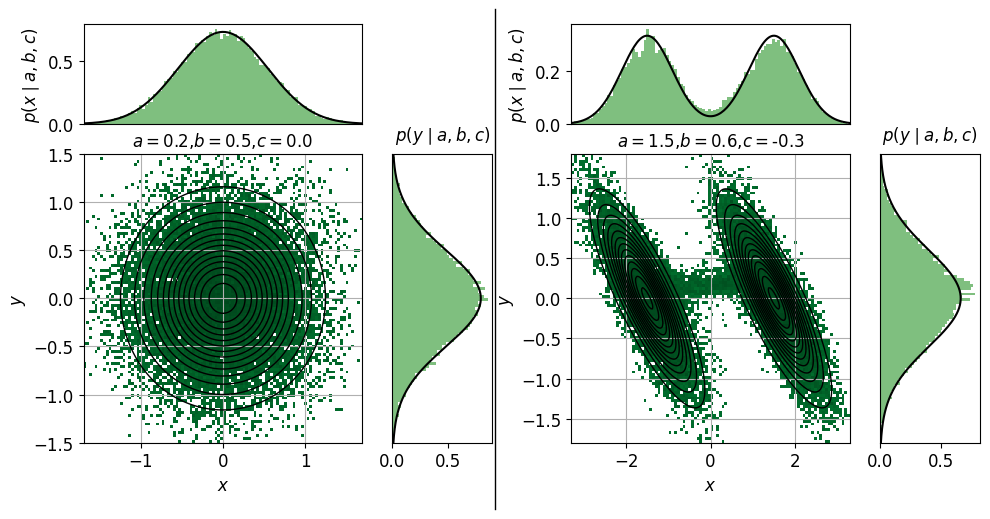

In [ ]:
import numpy as np
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import pandas as pd
import matplotlib.pyplot as plt
import os

# Define parameter list
params = [
    (0.2, 0.5, 0.0),
    (0.2, 0.5, 0.2),
    (0.6, 0.8, 0.4),
    (1.0, 0.8, 0.2),
    (1.5, 0.6, -0.3)
]

# Drop the second parameter set
params_to_use = params[:1] + params[4:]

base_path = '/home/ssingh_hpc/BiFra01proj/GMM/eval_results20k_w128'
made_list = [10]
run = 1

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes = axes.flatten()
# Add separating lines between subplots
fig_width, fig_height = fig.get_size_inches()
for x in [0.5]:  # one vertical line at mid-width
    fig.add_artist(plt.Line2D([x, x], [0, 1], transform=fig.transFigure, color='k', lw=1))
#for y in [0.5]:  # one horizontal line at mid-height
 #   fig.add_artist(plt.Line2D([0, 1], [y, y], transform=fig.transFigure, color='k', lw=1))


for idx, (a, b, c) in enumerate(params_to_use):
    ax = axes[idx]

    for made in made_list:
        file_path = os.path.join(
            base_path,
            f'made{made}',
            f'run{run}',
            f'GMM_vol{a}_mass{b}_beta{c}.npz'
        )

        if not os.path.exists(file_path):
            print(f"File not found: {file_path}")
            continue

        data = np.load(file_path, allow_pickle=True)['result']
        samples_sim = np.stack([data[3], data[4]], axis=1)
        samples_sim = torch.tensor(samples_sim, dtype=torch.float32).to(device)

        plt.sca(ax)
        joint_contour_with_marginals(samples_sim, made, a, b, c, ax)
        ax.set_title(rf"$a=${a},$b=${b},$c=${c}",fontsize=12)

# Hide unused subplots
for ax in axes[len(params_to_use):]:
    ax.axis('off')
plt.tight_layout()
#plt.savefig("Made10_GMM_20k_run1_v4.pdf")
plt.show()
